In [1]:
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 35
bound = 5
output = elliptic_fourier_expansions(level, bound)
print(len(output))
print()
print(output)
print()
print(output[0])
print()
print(output[0][1])

1

[('35a1', [(1, 1), (2, 0), (3, 1), (4, -2), (5, -1)])]

('35a1', [(1, 1), (2, 0), (3, 1), (4, -2), (5, -1)])

[(1, 1), (2, 0), (3, 1), (4, -2), (5, -1)]


In [32]:
nth_prime(400)

2741

In [2]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 35
bound =2800
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
prime_list_no_offset=[pair for pair in expansion if is_prime(pair[0])]
coeffs_list=[pair[1] for pair in prime_list_no_offset]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run12mar26no701.txt', 'wb') as wfile:
    pickle.dump(prime_list_no_offset, wfile) 
    
with open('/Users/barrybrent/data2/run12mar26no702.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

label: 35a1
(1, 0)
(2, 2)
(3, -3)
(4, 2)
(5, -10)
(6, 23)
(7, 42)
(8, -38)
(9, -48)
(10, 52)
(11, 55)
(12, -25)
(13, -455)
(14, -320)
(15, 1142)
(16, 330)
(17, -1683)
(18, -382)
(19, 2489)
(20, 5652)
(21, -4098)
(22, -16465)
(23, 10833)
(24, 28087)
(25, -15935)
(26, -60045)
(27, -24429)
(28, 155052)
(29, 119306)
(30, -360992)
(31, -249209)
(32, 668266)
(33, 750736)
(34, -891563)
(35, -2453888)
(36, 1210394)
(37, 6322301)
(38, -1978829)
(39, -13643243)
(40, -595748)
(41, 27659010)
(42, 16928368)
(43, -59320693)
(44, -60505949)
(45, 125259857)
(46, 161980929)
(47, -212638434)
(48, -422811705)
(49, 264946080)
(50, 1101459127)
(51, -218560452)
(52, -2655005273)
(53, -240150155)
(54, 5669968541)
(55, 2542801240)
(56, -11246432564)
(57, -10524810565)
(58, 21995334144)
(59, 32083585751)
(60, -40070191200)
(61, -83458181449)
(62, 58557621215)
(63, 203905991031)
(64, -48957716822)
(65, -483927302310)
(66, -63985198606)
(67, 1081583648376)
(68, 496935413965)
(69, -2215609358505)
(70, -1888492879

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


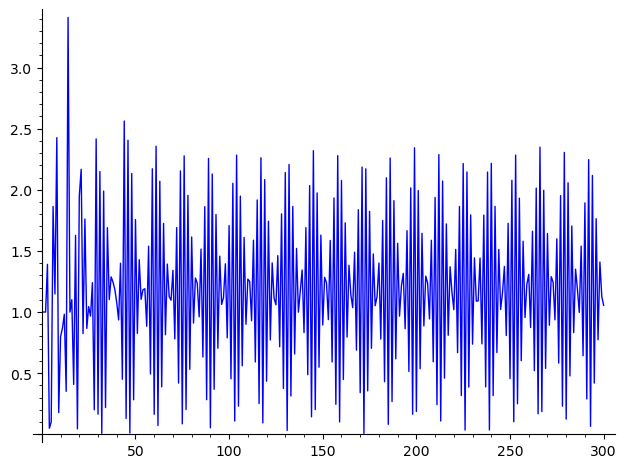

In [3]:
import pickle
from sage.all import sigma, nth_prime
import ast


with open('/Users/barrybrent/data2/run12mar26no702.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 301):
    print(n)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        if minn>0:
            log_minn=log(minn)
            log_mins_list.append((n,log_minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run12mar26no703.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run12mar26no704.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run12mar26no705.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped


Data range: n = 1 to 300
Number of data points: 300
Min modulus range: 0.007207 to 3.410247

Stage A: degree-2 polynomial detrend
  lag-1 autocorrelation of residuals: -0.8872
  ACF crosses zero within 100 lags: True
  --> Residual is oscillatory or low-autocorrelation. Polynomial detrend is sufficient.

Final detrending method: Polynomial (degree 2)
  Detrended data std dev: 0.6973

AR(1) lag-1 autocorrelation (rho): -0.8872
Frequency bins tested: 147
Bonferroni-corrected per-bin alpha: 95% -> 0.000340,  99% -> 0.000068

SIGNIFICANT FFT PEAKS  (period <= N/3 = 100, Bonferroni-corrected)
Rank   Period       Frequency    Power           Signif.   
---------------------------------------------------------------------------
1            2.16   0.463333     1.32e+04   99%

MULTI-SCALE PERIOD DETECTION
  Period       Scale           ACF strength    Role                
  ------------------------------------------------------------
      39.0    MA(37)              0.2122      FUNDAMENTAL
  

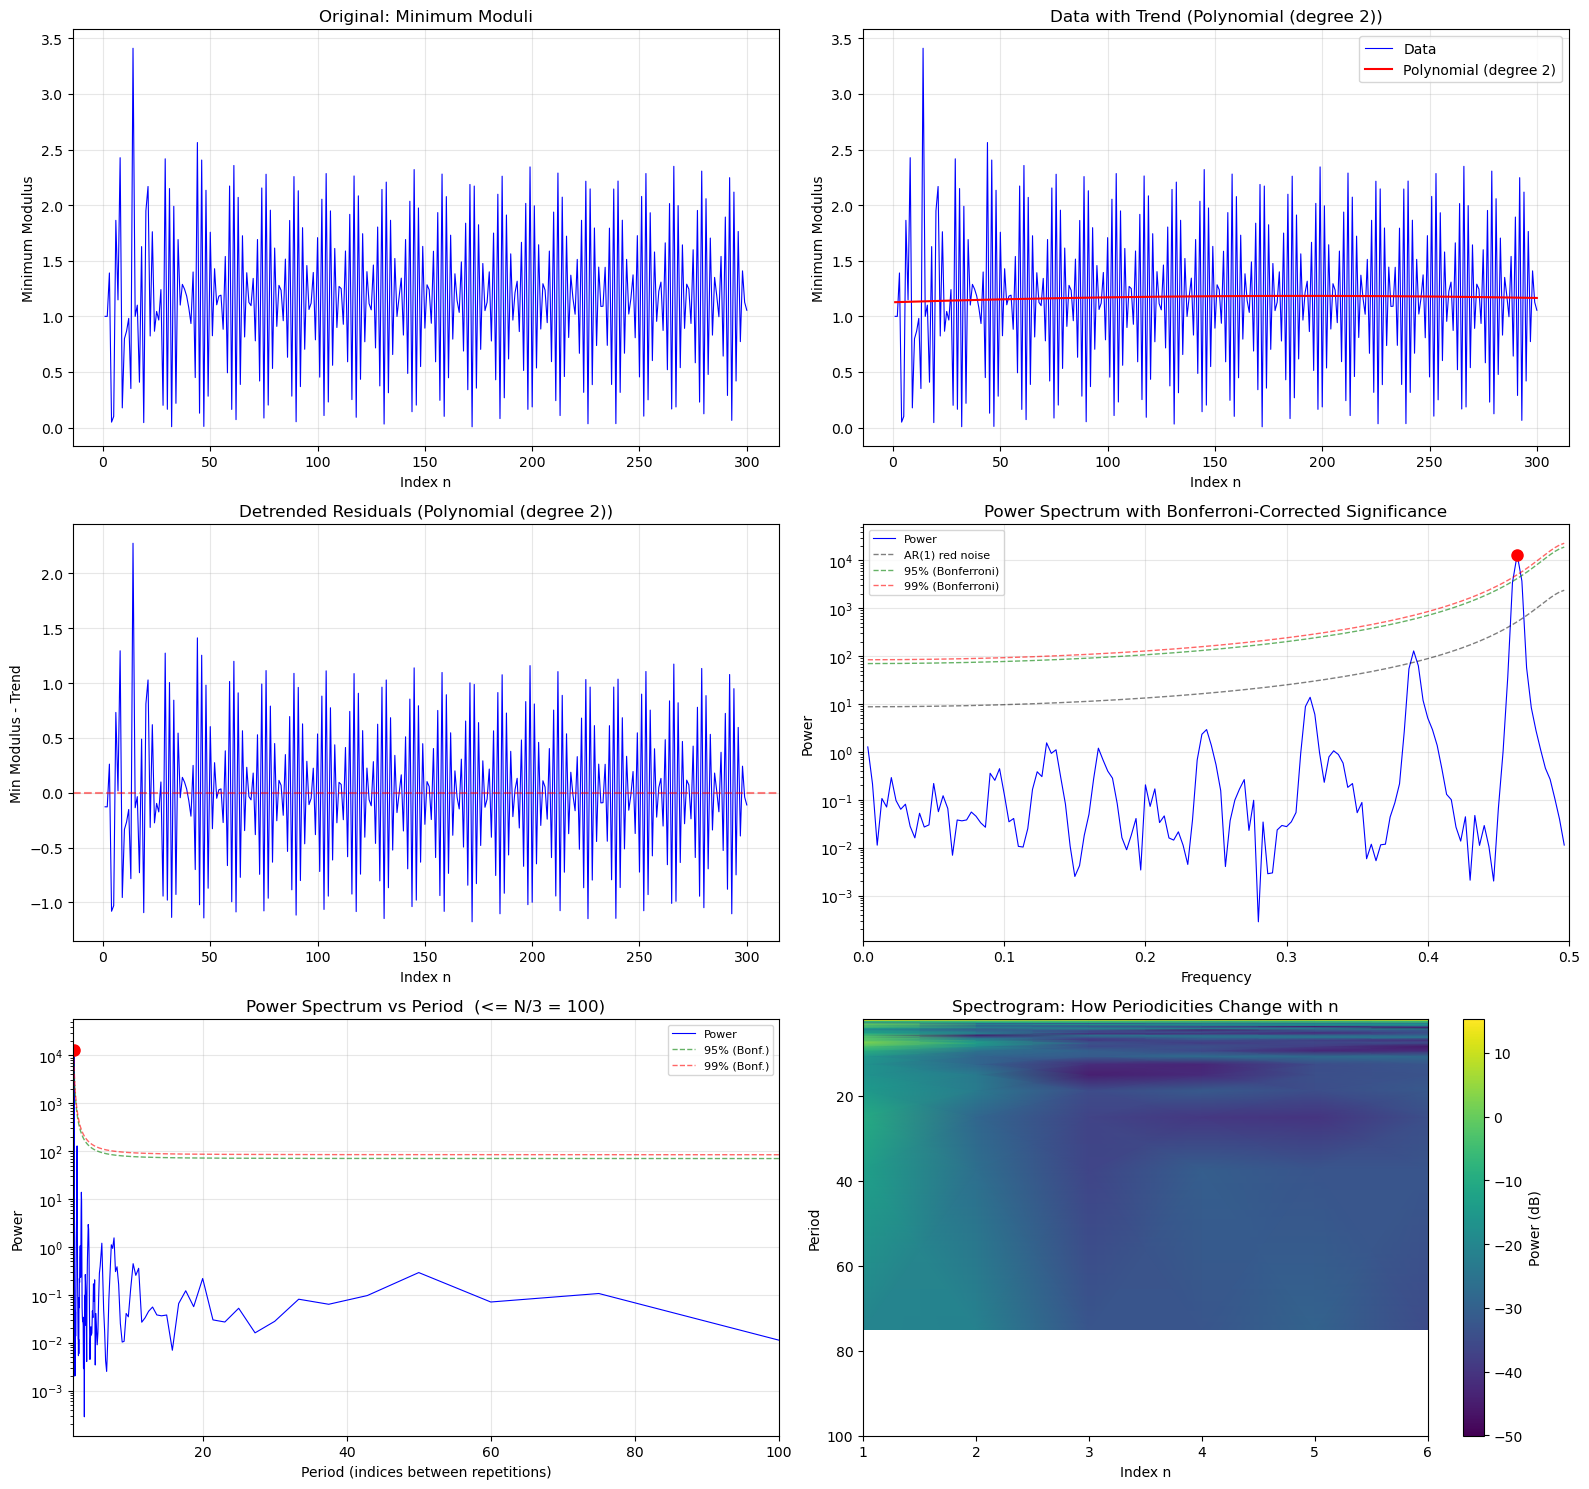


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run12mar26no705.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)
# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v8)
#
# KEY FIX: The detrending strategy now adapts to the data shape instead
# of always using a local smoother.
#
# Problem with v3/v4: A Savitzky-Golay filter with window > period
# absorbs the real oscillation into the "trend" and destroys it.
# For Figure 1 (ramp-plateau), a wide SG window was needed; for
# Figure 15B (periodic with period ~60), it was catastrophic.
#
# Solution: Use a two-stage approach:
#   Stage A: Fit a low-order polynomial (degree 2) to capture any
#            broad drift (linear/quadratic growth).  This is gentle
#            enough to never absorb oscillations with period < N/3.
#   Stage B: Check whether the polynomial residuals still have a
#            problematic trend shape (high lag-1 autocorrelation AND
#            the autocorrelation function is monotonically decaying,
#            i.e. trend-like rather than oscillation-like).  Only if
#            so, escalate to a Savitzky-Golay filter ‚Äî but cap its
#            window at max_credible_period to protect real periodicities.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. ADAPTIVE DETRENDING  (safe for both trended and periodic data)
# ==============================================================================
max_credible_period = N / 3.0

# --- Stage A: low-order polynomial (captures broad drift only) ---
poly_deg = 2
poly_coeffs = np.polyfit(indices, minmoduli, deg=poly_deg)
poly_trend = np.polyval(poly_coeffs, indices)
resid_poly = minmoduli - poly_trend

# Measure whether the residual looks "trend-like" or "oscillation-like"
# by examining the autocorrelation at several lags.
acf_lags = min(50, N // 4)
acf = np.correlate(resid_poly - resid_poly.mean(), resid_poly - resid_poly.mean(), 'full')
acf = acf[N-1:]  # positive lags only
acf = acf / acf[0]  # normalize

# A trend residual has ACF that decays monotonically from 1 toward 0.
# A periodic residual has ACF that oscillates (dips below 0, comes back up).
# Check: does the ACF cross zero within the first max_credible_period lags?
check_range = min(int(max_credible_period), len(acf))
acf_crosses_zero = np.any(acf[1:check_range] < 0)
r1_poly = np.corrcoef(resid_poly[:-1], resid_poly[1:])[0, 1]

print(f"\nStage A: degree-{poly_deg} polynomial detrend")
print(f"  lag-1 autocorrelation of residuals: {r1_poly:.4f}")
print(f"  ACF crosses zero within {check_range} lags: {acf_crosses_zero}")

# Decision: if ACF crosses zero, the residual is oscillatory (good ‚Äî
# the polynomial removed drift without eating periodicity).
# If ACF does NOT cross zero and r1 is high, there's residual trend
# that needs stronger detrending.

TREND_THRESHOLD = 0.85  # residual autocorrelation above this = still trended

if not acf_crosses_zero and abs(r1_poly) > TREND_THRESHOLD:
    # --- Stage B: local smoother needed, but window capped to protect periodicity ---
    print(f"  --> Residual is trend-like (r1={r1_poly:.4f}, no zero-crossing).")
    print(f"      Escalating to Savitzky-Golay, window capped at {int(max_credible_period)}.")

    sg_poly_order = 3
    # Cap the window: must be odd, and must not exceed max_credible_period
    max_sg_win = int(max_credible_period)
    if max_sg_win % 2 == 0:
        max_sg_win -= 1
    max_sg_win = max(max_sg_win, sg_poly_order + 2)  # minimum valid window

    candidate_windows = [w for w in range(21, max_sg_win + 1, 10) if w % 2 == 1]
    if not candidate_windows:
        candidate_windows = [max_sg_win]

    best_win, best_score = candidate_windows[0], np.inf
    for win in candidate_windows:
        trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
        resid = minmoduli - trend
        r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
        if r1 < best_score:
            best_score = r1
            best_win = win

    smooth_trend = signal.savgol_filter(minmoduli, window_length=best_win,
                                        polyorder=sg_poly_order)
    detrended = minmoduli - smooth_trend
    detrend_label = f"Savitzky-Golay (win={best_win}, order={sg_poly_order})"
    print(f"      Selected window: {best_win}")
    print(f"      lag-1 autocorrelation of residuals: {best_score:.4f}")
else:
    # Stage A was sufficient
    smooth_trend = poly_trend
    detrended = resid_poly
    detrend_label = f"Polynomial (degree {poly_deg})"
    print(f"  --> Residual is oscillatory or low-autocorrelation. "
          f"Polynomial detrend is sufficient.")

print(f"\nFinal detrending method: {detrend_label}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = detrended * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
variance = np.var(detrended)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS  (FFT)
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

# ==============================================================================
# 5b. MULTI-SCALE FUNDAMENTAL PERIOD DETECTION
# ==============================================================================
# Waveforms can have structure at multiple scales: e.g. a sawtooth with
# period ~60 is built from small teeth with period ~3.  The FFT, naive ACF,
# and time-domain peak-finding all latch onto the finest scale because it
# has the sharpest features.
#
# Strategy: detect periodicity at MULTIPLE SCALES by progressively smoothing
# the detrended signal and re-measuring.  At each scale, compute the ACF
# and find its first peak above a quality threshold.  Collect all detected
# periods across scales and report them hierarchically.
#
# Scale 0: raw detrended signal (captures finest structure)
# Scale k: smoothed with a moving average of width 2k+1
#
# The LONGEST period detected at any scale is the fundamental; shorter
# periods are sub-cycle structure.

detected_periods = []  # list of (period, scale_label, acf_strength)

# Scales to try: raw, then moving-average windows of increasing width
# We go up to window ~ max_credible_period / 2 to avoid smoothing away
# the coarsest structure we could detect.
smooth_widths = [1]  # 1 = no smoothing (raw)
w = 3
while w < max_credible_period / 2:
    smooth_widths.append(w)
    w = max(w + 2, int(w * 1.5))
    if w % 2 == 0:
        w += 1

for sw in smooth_widths:
    if sw == 1:
        smoothed = detrended.copy()
        scale_label = "raw"
    else:
        # Moving average
        kernel = np.ones(sw) / sw
        smoothed = np.convolve(detrended, kernel, mode='same')
        scale_label = f"MA({sw})"

    # Compute ACF of smoothed signal
    sm_centered = smoothed - smoothed.mean()
    acf_sm = np.correlate(sm_centered, sm_centered, 'full')
    acf_sm = acf_sm[N-1:]
    if acf_sm[0] > 0:
        acf_sm = acf_sm / acf_sm[0]
    else:
        continue

    # Find first ACF peak above zero with lag >= sw+1
    # (don't count lags shorter than the smoothing window ‚Äî those are artifacts)
    search_start = max(2, sw + 1) if sw > 1 else 2
    search_end = min(int(max_credible_period), len(acf_sm) - 1)
    if search_start >= search_end:
        continue

    acf_slice = acf_sm[search_start:search_end+1]
    peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)

    if len(peaks_in_slice) > 0:
        best_peak = peaks_in_slice[0]  # first peak above threshold
        lag = best_peak + search_start
        strength = acf_sm[lag]

        # Check this isn't a duplicate of an already-detected period
        is_new = True
        for (prev_p, _, _) in detected_periods:
            if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                is_new = False
                break
        if is_new:
            detected_periods.append((float(lag), scale_label, float(strength)))

# Sort by period length (longest first)
detected_periods.sort(key=lambda x: x[0], reverse=True)

# The fundamental is the longest detected period; others are sub-structure
fund_period = None
fund_method = None
fund_strength = None
sub_periods = []

if detected_periods:
    fund_period = detected_periods[0][0]
    fund_method = f"multi-scale ACF ({detected_periods[0][1]})"
    fund_strength = detected_periods[0][2]
    sub_periods = detected_periods[1:]

# ==============================================================================
# 5c. REPORTING
# ==============================================================================
print("\n" + "="*75)
print(f"SIGNIFICANT FFT PEAKS  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
else:
    print("  No FFT peaks exceed the Bonferroni-corrected significance threshold.")

# --- Multi-scale period detection ---
print("\n" + "="*75)
print("MULTI-SCALE PERIOD DETECTION")
print("="*75)
if detected_periods:
    print(f"  {'Period':<12} {'Scale':<15} {'ACF strength':<15} {'Role':<20}")
    print(f"  {'-'*60}")
    for i, (p, label, strength) in enumerate(detected_periods):
        role = "FUNDAMENTAL" if i == 0 else "sub-cycle structure"
        print(f"  {p:>8.1f}    {label:<15} {strength:>10.4f}      {role}")
else:
    print("  No periodicity detected at any scale.")

# --- Harmonic analysis ---
if fund_period is not None and significant_peaks:
    print(f"\n  Harmonic analysis (FFT peaks as multiples of fundamental "
          f"= {fund_period:.1f}):")
    print(f"  {'Rank':<6} {'FFT Period':<12} {'T_fund / T_peak':<18} "
          f"{'Nearest int':<12} {'Harmonic?':<10}")
    print(f"  {'-'*70}")
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        ratio = fund_period / periods[pi]
        nearest = round(ratio)
        is_harmonic = (nearest >= 1 and
                       abs(ratio - nearest) < 0.15 * max(nearest, 1))
        tag = f"~{nearest}x" if is_harmonic else "independent"
        print(f"  {rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     "
              f"{nearest:>6}     {tag}")

# --- Summary ---
print("\n" + "="*75)
print("SUMMARY")
print("="*75)
if fund_period is not None and fund_strength > 0.2:
    print(f"  Fundamental period: {fund_period:.1f}  (via {fund_method}, "
          f"ACF strength {fund_strength:.4f})")
    if sub_periods:
        sub_str = ", ".join(f"{p:.1f}" for p, _, _ in sub_periods)
        print(f"  Sub-cycle structure at period(s): {sub_str}")
    if significant_peaks:
        dominant_fft_period = periods[significant_peaks[0][0]]
        ratio_to_fund = fund_period / dominant_fft_period
        nearest = round(ratio_to_fund)
        if nearest > 1 and abs(ratio_to_fund - nearest) < 0.15 * nearest:
            print(f"  Dominant FFT peak (period {dominant_fft_period:.2f}) is the "
                  f"~{nearest}x harmonic of the fundamental.")
            print(f"  The waveform is non-sinusoidal (sharp/angular features "
                  f"concentrate power in upper harmonics).")
        elif nearest <= 1:
            print(f"  Dominant FFT peak (period {dominant_fft_period:.2f}) matches "
                  f"the fundamental.")
elif fund_period is not None and fund_strength <= 0.2:
    print("  Weak periodicity detected (ACF strength < 0.2) ‚Äî likely not significant.")
else:
    print("  The data has no statistically significant periodicity.")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(3, 2, figsize=(16, 15))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=detrend_label)
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Trend ({detrend_label})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals ({detrend_label})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Power spectrum with corrected confidence bands
axes[1, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[1, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[1, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[1, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[1, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[1, 1].set_xlabel('Frequency')
axes[1, 1].set_ylabel('Power')
axes[1, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, 0.5)

# 6.5  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[2, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[2, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[2, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[2, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[2, 0].set_xlabel('Period (indices between repetitions)')
axes[2, 0].set_ylabel('Power')
axes[2, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[2, 0].legend(fontsize=8)
axes[2, 0].grid(True, alpha=0.3)
axes[2, 0].set_xlim(2, max_credible_period)

# 6.6  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(detrended, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[2, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[2, 1].set_xlabel('Index n')
axes[2, 1].set_ylabel('Period')
axes[2, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[2, 1].set_ylim(2, min(100, max_credible_period))
axes[2, 1].invert_yaxis()
plt.colorbar(im, ax=axes[2, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)
